In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1=pd.read_csv("/content/drive/MyDrive/Ai/i1.csv")
df2=pd.read_csv("/content/drive/MyDrive/Ai/i2.csv")

In [ ]:
df=df1.merge(df2,how='outer')
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         15621 non-null  object 
 1   Timestamp    15621 non-null  object 
 2   Invoice No.  15621 non-null  int64  
 3   Item Name    15621 non-null  object 
 4   Price        15621 non-null  float64
 5   Qty.         15621 non-null  float64
 6   Sub Total    15621 non-null  float64
 7   Discount     15621 non-null  float64
 8   Tax          15621 non-null  float64
 9   Final Total  15621 non-null  float64
 10  Table No.    15613 non-null  float64
 11  Server Name  15621 non-null  object 
 12  Covers       15621 non-null  int64  
 13  Variation    15 non-null     object 
 14  Category     15621 non-null  object 
 15  HSN          0 non-null      float64
dtypes: float64(8), int64(2), object(6)
memory usage: 1.9+ MB


In [ ]:
df.head()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
0,2023-04-01,2023-04-01 13:16:03,23465,Babycorn Manchurian,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,Veg Starters,NaN
1,2023-04-01,2023-04-01 13:16:03,23465,Chicken Kati Roll,120.0,1.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,NON VEG STARTERS CHICKEN,NaN
2,2023-04-01,2023-04-01 13:16:03,23465,Paneer Butter Masala,150.0,2.0,300.0,0.0,15.0,315.0,20.0,biller,0,NaN,Veg Gravy,NaN
3,2023-04-01,2023-04-01 13:16:03,23465,Pulka (2 No),40.0,3.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,Indian Breads,NaN
4,2023-04-01,2023-04-01 13:16:03,23465,Schewan Chicken Fried Rice,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,NON VEG BRIYANI & RICE,NaN


In [ ]:
df.describe()

,Invoice No.,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Covers,HSN
count,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15613.000000,15621.0,0.0
mean,25989.963127,116.608988,1.338839,147.407080,1.262818,7.303668,153.447930,18.068340,0.0,NaN
std,1433.192998,63.663769,0.949814,210.127442,6.656396,10.461474,219.678163,17.191377,0.0,NaN
min,23465.000000,12.000000,1.000000,12.000000,0.000000,0.000000,12.600000,1.000000,0.0,NaN
25%,24751.000000,50.000000,1.000000,80.000000,0.000000,4.000000,84.000000,4.000000,0.0,NaN
50%,25980.000000,140.000000,1.000000,150.000000,0.000000,7.000000,147.000000,12.000000,0.0,NaN
75%,27274.000000,160.000000,1.000000,170.000000,0.000000,8.500000,178.500000,26.000000,0.0,NaN
max,28389.000000,770.000000,28.000000,21560.000000,288.000000,1078.000000,22638.000000,50.000000,0.0,NaN


In [ ]:
df.isna().sum()

,0
Date,0
Timestamp,0
Invoice No.,0
Item Name,0
Price,0
Qty.,0
Sub Total,0
Discount,0
Tax,0
Final Total,0


In [ ]:
df=df.drop(["Discount","Table No.","Server Name","Covers","Variation","HSN"],axis=1)

In [ ]:
a=df["Final Total"].sum()
a

np.float64(2397010.12)

In [ ]:
b=df["Invoice No."].nunique()

In [ ]:
c=a/b
c

np.float64(486.70256243654825)

<Axes: xlabel='Item Name'>

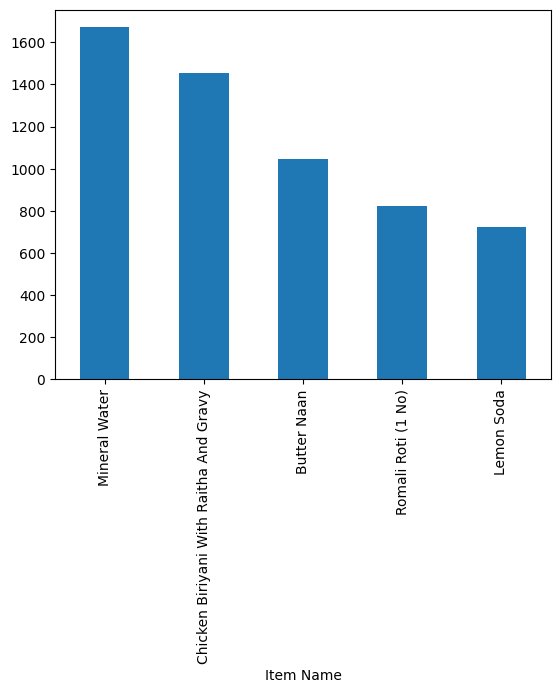

In [ ]:
b=df.groupby('Item Name')['Qty.'].sum().sort_values(ascending=False)[0:5]
#sns.barplot(b)
b.plot(kind="bar")

<Axes: xlabel='Item Name'>

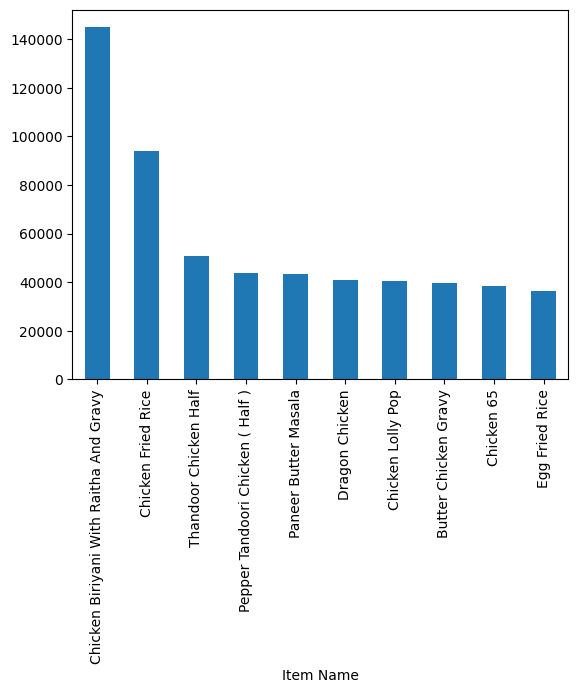

In [ ]:
e=df.groupby("Item Name")["Price"].sum().sort_values(ascending=False)[0:10]
e.plot(kind="bar")

In [ ]:
e=df.groupby("Date")["Final Total"].sum().loc["2023-09-15"]
e

np.float64(21042.02)

In [ ]:
df[df["Date"]=="2023-09-15"]["Final Total"].sum()

np.float64(21042.02)

In [ ]:
df[(df["Date"]=="2023-09-15") & (df["Item Name"]=="Chicken Noodles")]["Qty."].sum()

np.float64(7.0)

In [ ]:
e=df.groupby("Invoice No.")["Final Total"].sum()
#e[e>2000]
e[e==2887.50]


,Final Total
Invoice No.,
28126,2887.5


In [ ]:

z=df[(df["Invoice No."]==28145)]
z["Item Name"]


,Item Name
14830,Butter Chicken Gravy
14831,Butter Chicken Gravy
14832,Butter Naan
14833,Chicken Biriyani With Raitha And Gravy
14834,Chicken Chettinad Gravy
14835,Chicken Pallipalayam Gravy
14836,Fish 65
14837,Garlic Naan
14838,Gobi- 65
14839,Kadai Paneer


In [ ]:
z["Qty."].sum()


np.float64(40.0)

In [ ]:
z["Final Total"].sum()

np.float64(4078.68)

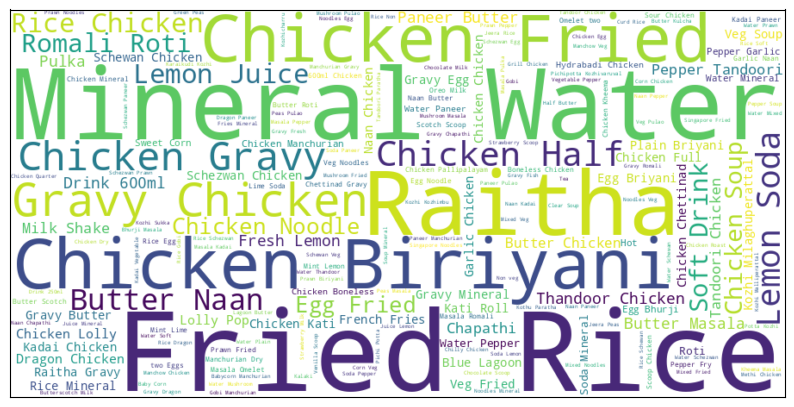

In [ ]:
from wordcloud import WordCloud
txt=' '.join(df["Item Name"].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=900,height=450).generate(txt)
fig,ax =plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='bilinear')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

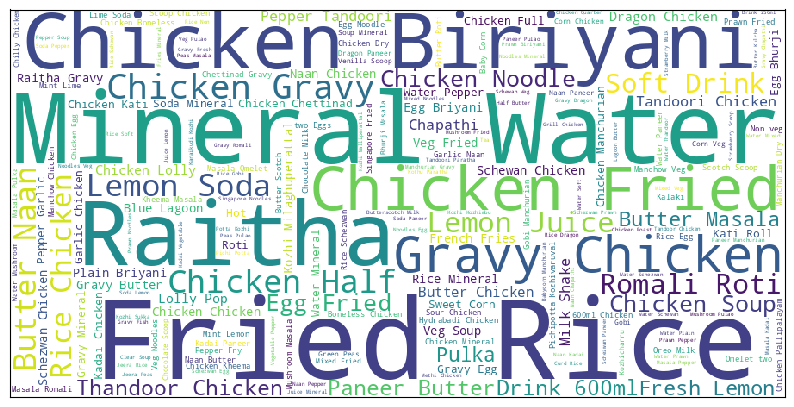

In [ ]:
from wordcloud import WordCloud
txt=' '.join(df["Item Name"].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=900,height=450).generate(txt)
fig,ax =plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

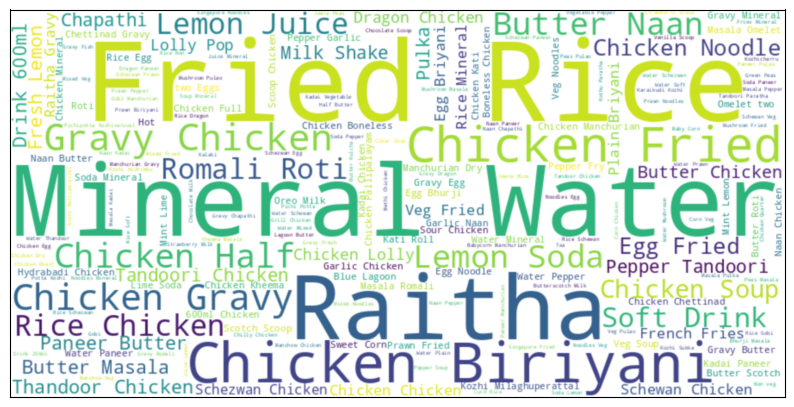

In [ ]:
from wordcloud import WordCloud
txt=' '.join(df["Item Name"].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=900,height=450).generate(txt)
fig,ax =plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='bicubic')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

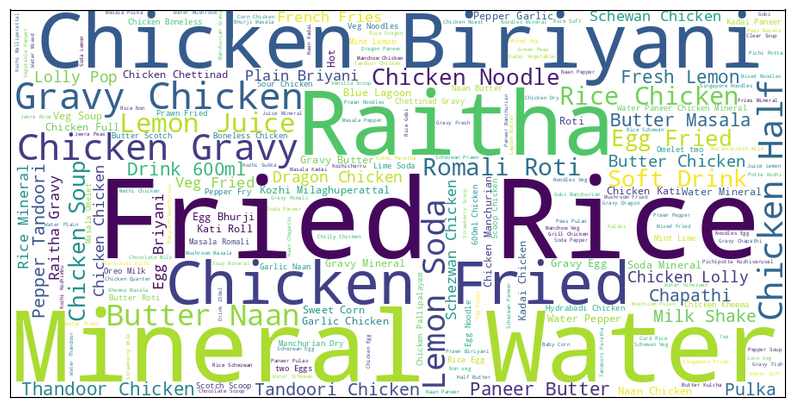

In [ ]:
from wordcloud import WordCloud
txt=' '.join(df["Item Name"].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=900,height=450).generate(txt)
fig,ax =plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='blackman')
ax.set_xticks([])
ax.set_yticks([])
plt.show()